In [1]:
import os 
import numpy as np
from PIL import Image
import matplotlib.pyplot as plt
import torch

In [2]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("device:", device)

device: cuda


In [3]:
def load_png_as_rgb(png_path):
    with Image.open(png_path) as img:
        img = img.convert("RGB")
        arr = np.array(img, dtype = np.uint8)

    assert arr.ndim == 3 and arr.shape[2] == 3
    assert arr.dtype == np.uint8
    return arr

In [4]:
from sam2.build_sam import build_sam2
from sam2.automatic_mask_generator import SAM2AutomaticMaskGenerator

In [5]:
sam2_checkpoint = "/home/predm/sam2/checkpoints/sam2.1_hiera_large.pt"
model_cfg = "configs/sam2.1/sam2.1_hiera_l.yaml"

In [6]:
sam2 = build_sam2(model_cfg, sam2_checkpoint, device=device, apply_postprocessing=False)

In [20]:
mask_generator_2 = SAM2AutomaticMaskGenerator(
    model=sam2,
    points_per_side=64,
    points_per_batch=128,
    pred_iou_thresh=0.7,
    stability_score_thresh=0.92,
    stability_score_offset=0.7,
    crop_n_layers=1,
    box_nms_thresh=0.7,
    crop_n_points_downscale_factor=2,
    min_mask_region_area=25.0,
    use_m2m=True,
)

In [8]:
import csv, random

with open("/home/predm/skimage_segmentation/paired.csv", newline="", encoding="utf-8") as f:
    rows = list(csv.DictReader(f))

#random.seed(42)
idxs = sorted(random.sample(range(len(rows)), k=min(10, len(rows))))
idxs

[10, 19, 45, 77, 81, 88, 106, 114, 122, 131]

In [21]:
i = idxs[0]
stem = rows[i]["stem"]
png_path = rows[i]["png_path"].strip()
npz_path = rows[i]["npz_path"].strip()


image = load_png_as_rgb(png_path)

data = np.load(npz_path)
ice_mask = data["ice_mask"]          
labels = data["labels"]  

masks = mask_generator_2.generate(image)

print("masks:", len(masks))
print("keys:", masks[0].keys())
print("ice_mask unique:", np.unique(ice_mask))
print("ice pixels:", (~ice_mask).sum())
print("water pixels:", ice_mask.sum())
print(stem)

masks: 22
keys: dict_keys(['segmentation', 'area', 'bbox', 'predicted_iou', 'point_coords', 'stability_score', 'crop_box'])
ice_mask unique: [False  True]
ice pixels: 100268
water pixels: 161876
S1A_EW_GRDM_1SDH_20200101T074515_20200101T074619_030604_038191_EBD1.SAFE_1_1


In [24]:
def show_anns(anns, borders=True):
    if len(anns) == 0:
        return
    sorted_anns = sorted(anns, key=(lambda x: x['area']), reverse=True)
    ax = plt.gca()
    ax.set_autoscale_on(False)

    img = np.ones((sorted_anns[0]['segmentation'].shape[0], sorted_anns[0]['segmentation'].shape[1], 4))
    img[:, :, 3] = 0
    for ann in sorted_anns:
        m = ann['segmentation']
        color_mask = np.concatenate([np.random.random(3), [0.5]])
        img[m] = color_mask 
        if borders:
            import cv2
            contours, _ = cv2.findContours(m.astype(np.uint8), cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_NONE) 
            # Try to smooth contours
            contours = [cv2.approxPolyDP(contour, epsilon=0.01, closed=True) for contour in contours]
            cv2.drawContours(img, contours, -1, (0, 0, 1, 0.4), thickness=1) 

    ax.imshow(img)

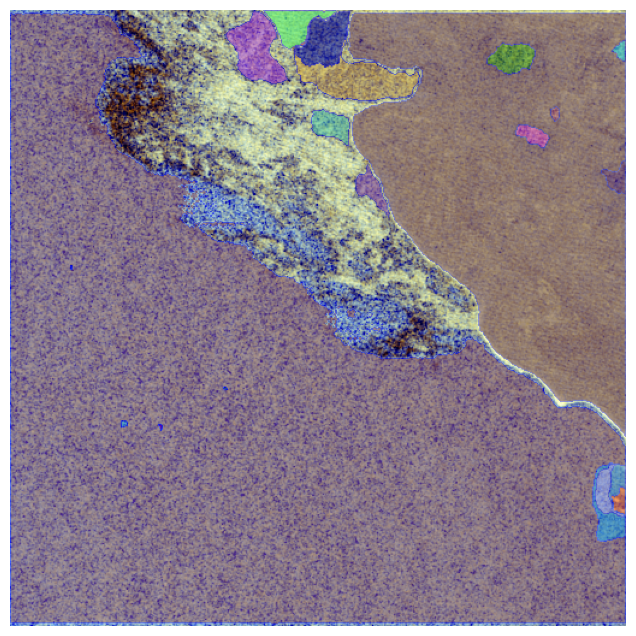

In [25]:
plt.figure(figsize=(8, 8))
plt.imshow(image)
show_anns(masks)
plt.axis("off")
plt.show()

In [26]:
H, W = ice_mask.shape
sam2_binary = np.zeros((H, W), dtype = bool)

In [27]:
for ann in masks:
    m = ann["segmentation"]
    if m.sum() == 0:
        continue

    water_fraction = ice_mask[m].mean()
    sam2_binary[m] = (water_fraction > 0.5)

print("GT water pixels:", ice_mask.sum())
print("Pred water pixels:", sam2_binary.sum())

GT water pixels: 161876
Pred water pixels: 154811


In [28]:
intersection = np.logical_and(sam2_binary, ice_mask).sum()
union        = np.logical_or(sam2_binary, ice_mask).sum()

iou = intersection / union if union > 0 else float("nan")
print("IoU (water):", iou)

IoU (water): 0.9486991729841489


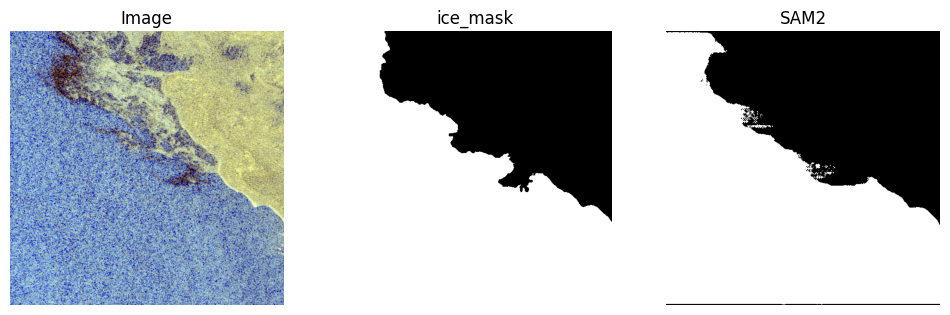

In [29]:
plt.figure(figsize=(12,4))

plt.subplot(1,3,1)
plt.imshow(image)
plt.title("Image")
plt.axis("off")

plt.subplot(1,3,2)
plt.imshow(ice_mask, cmap="gray")
plt.title("ice_mask")
plt.axis("off")

plt.subplot(1,3,3)
plt.imshow(sam2_binary, cmap="gray")
plt.title("SAM2")
plt.axis("off")

plt.show()

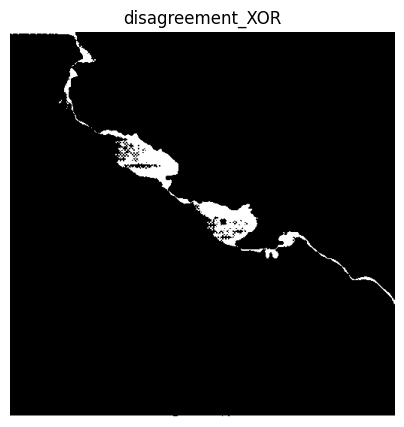

In [30]:
errors = sam2_binary ^ ice_mask
plt.figure(figsize=(5,5))
plt.imshow(errors, cmap="gray")
plt.title("disagreement_XOR")
plt.axis("off")
plt.show()